In [ ]:
import os
import openpyxl
from openpyxl.utils import range_boundaries

def clean_excel_files(source_folder, dest_folder):
    for root, dirs, files in os.walk(source_folder):
        for filename in files:
            if filename.endswith('.xlsx') and not filename.startswith('~$'):
                input_file_path = os.path.join(root, filename)
                relative_path = os.path.relpath(root, source_folder)
                output_dir_path = os.path.join(dest_folder, relative_path)
                output_file_path = os.path.join(output_dir_path, filename)

                if not os.path.exists(output_dir_path):
                    os.makedirs(output_dir_path)

                print(f"Processing: {input_file_path}")

                try:
                    wb = openpyxl.load_workbook(input_file_path, data_only=False)
                    sheet_modified = False

                    for sheet_name in wb.sheetnames:
                        # ROA setup
                        scanned_rows = set()
                        sheet = wb[sheet_name]

                        max_row_scan = min(6, sheet.max_row)

                        for row_idx in range(1, max_row_scan + 1):
                            for cell in sheet[row_idx]:
                                if cell.value and "ROA" in str(cell.value).upper():
                                    scanned_rows.add(cell.column)
                        
                        scanned_columns = list(scanned_rows)
                        if not scanned_columns:
                            print(f"  - No 'ROA' columns found in sheet '{sheet_name}' (rows 1-6)")
                            continue

                        print(f"  - Found ROA columns in sheet '{sheet_name}': {scanned_columns}")
                        start_row = 7

                        rows_to_remove = []

                        for row_idx in range(sheet.max_row, start_row - 1, -1):
                            # row_data = list(sheet.iter_rows(min_row=row_idx, max_row=row_idx, values_only=True))[0]
                            remove_this_row = False

                            for col_idx in scanned_columns:
                                cell_getter = sheet.cell(row=row_idx, column=col_idx)
                                cell_val = cell_getter.value

                                if cell_val is None:
                                    continue
                                if isinstance(cell_val, (int, float)) and cell_val == 0:
                                    remove_this_row = True
                                    break
                                if isinstance(cell_val, str) and cell_val.strip().upper() == "NA":
                                    remove_this_row = True
                                    break

                            if remove_this_row:
                                rows_to_remove.append(row_idx)

                        if rows_to_remove:
                            rows_to_remove.sort(reverse=True)
                            for row_idx in rows_to_remove:
                                sheet.delete_rows(row_idx, 1)
                            sheet_modified = True
                            print(f"  - Removed {len(rows_to_remove)} rows from sheet '{sheet_name}'")

                    wb.save(output_file_path)
                    if sheet_modified:
                        print(f"  -> Saved cleaned file to: {output_file_path}")
                    else:
                        print(f"  -> No changes needed. Saved copy to: {output_file_path}")

                except Exception as e:
                    print(f"Error processing file {filename}: {e}")

source_directory = "E:\\hneu\\data2"
destination_directory = "E:\\hneu\\data4"

if __name__ == "__main__":
    if os.path.exists(source_directory):
        clean_excel_files(source_directory, destination_directory)
        print("\nAll files processed successfully.")
    else:
        print(f"Error: Source directory '{source_directory}' does not exist.")


# Preprocessing data

In [6]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import re
import os

capex_dir = Path("E:/hneu/xlsm_data/data_tong_hop")
capex_files = list(capex_dir.glob("*.xlsm"))
print(f"Found {len(capex_files)} files.")

def extract_capex_from_sheet(worksheet, sector):
    """
    Extract data from a worksheet that has columns:
    Col A: Country, Col B: Financial Year, Col C: Capex
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, year, capex = row[0], row[1], row[2]

        if country is None or capex is None or year is None:
            continue
            
        try:
            year_match = re.match("FY(\d{4})", year)
            year = int(year_match.group(1))
            if year < 2014 or year > 2024:
                raise ValueError("Not in the valid year range: 2014 to 2024")
        except (TypeError, ValueError):
            year = None
            print("Flagged for year range error")
    
        if isinstance(capex, str):
            capex = capex.replace(',', '').replace('(', '-').replace(')', '')
        try:
            capex = float(capex)
        except (TypeError, ValueError):
            capex = None
        
        if year >= 2014 and year <= 2024:
            data.append({
                "Country": country.strip() if isinstance(country, str) else country,
                "Sector": sector,
                "Year": year,
                "Capex": capex
            })
        
    return data

all_data = []
for file in capex_files:
    print(f"Processing {file.name}...")

    sector = os.path.splitext(file.name)[0]
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'final' not in wb.sheetnames:
            print(f"Skipping {file.name}...")
            wb.close()
            continue
    
        final_sheet = wb['final']
        file_data = extract_capex_from_sheet(final_sheet, sector=sector)
        all_data.extend(file_data)
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df = pd.DataFrame(all_data)
df.to_csv("E:\\hneu\\notebooks\\model_results\\capex_data.csv")

Found 5 files.
Processing Energy.xlsm...
Processing Healthcare.xlsm...
Processing Industrials.xlsm...
Processing Materials.xlsm...
Processing Real_Estate.xlsm...


In [ ]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import os
import re

risk_dir = Path("E:\\hneu\\xlsm_data\\inform_risk")
risk_files = list(risk_dir.glob("*.xlsx"))
print(f"Found {len(risk_files)} files.")

def extract_risk_from_sheet(worksheet, source_file):
    """
    Extract data from a worksheet that has columns:
    Col A: Iso3, Col B: IndicatorName, Col C: INFORMYear, Col D: IndicatorScore
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        iso3, indicator_name, year, score = row[0], row[1], row[2], row[3]

        if iso3 is None or year is None or score is None:
            continue
            
        try:
            year_match = re.search(r'\d{4}', str(year))
            if year_match:
                year = int(year_match.group())
            else:
                raise ValueError("No year found")
            
            if year < 2014 or year > 2025:
                raise ValueError("Not in the valid year range: 2014 to 2024")
        except (TypeError, ValueError) as e:
            print(f"Flagged for year range error: {year} - {e}")
            continue  # Skip this row entirely
    
        if isinstance(score, str):
            score = score.replace(',', '')
        try:
            score = float(score)
        except (TypeError, ValueError):
            score = None
        
        data.append({
            "Iso3": iso3.strip() if isinstance(iso3, str) else iso3,
            "IndicatorName": indicator_name.strip() if isinstance(indicator_name, str) else indicator_name,
            "Source": source_file,
            "Year": year,
            "IndicatorScore": score
        })
        
    return data

def extract_country_id_from_sheet(worksheet):
    """
    Extract country ID mapping from worksheet.
    Col A: country, Col B: country id
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, country_id = row[0], row[1]

        if country is None or country_id is None:
            continue
        
        data.append({
            "country": country.strip() if isinstance(country, str) else country,
            "country_id": country_id.strip() if isinstance(country_id, str) else country_id
        })
        
    return data

all_data = []
country_mapping = []

for file in risk_files:
    print(f"Processing {file.name}...")

    source = os.path.splitext(file.name)[0]
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'INFORM RISK INDEX' in wb.sheetnames:
            risk_sheet = wb['INFORM RISK INDEX']
            file_data = extract_risk_from_sheet(risk_sheet, source)
            all_data.extend(file_data)
        
        if 'country_id' in wb.sheetnames and not country_mapping:
            country_sheet = wb['country_id']
            country_data = extract_country_id_from_sheet(country_sheet)
            country_mapping.extend(country_data)
        
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df_risk = pd.DataFrame(all_data)
df_country = pd.DataFrame(country_mapping)

if not df_country.empty and not df_risk.empty:
    df_combined = pd.merge(df_risk, df_country, left_on='Iso3', right_on='country_id', how='left')
    df_combined.to_csv("E:\\hneu\\notebooks\\model_results\\inform_risk_data.csv", index=False)
else:
    print("No data to combine")
    df_risk.to_csv("E:\\hneu\\notebooks\\model_results\\inform_risk_data.csv", index=False)

Found 1 files.
Processing inform_risk.xlsx...


: 

In [9]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import os

risk_dir = Path("E:/hneu/xlsm_data/inform_risk")
risk_files = list(risk_dir.glob("*.xlsx"))
print(f"Found {len(risk_files)} files.")

def extract_risk_data(worksheet, risk_type):
    """
    Extract data from a worksheet with years in column A (starting row 2)
    and country names in row 1 (starting col B).
    Returns list of dicts: Country, RiskType, Year, Value.
    """
    data = []
    
    countries = []
    for cell in worksheet[1][1:]:
        if cell.value:
            countries.append(str(cell.value).strip())
    
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        year_val = row[0]
        if year_val is None:
            continue
        
        # Parse year
        try:
            year = int(year_val)
            if year < 2014 or year > 2025:
                print(f"Year {year} out of expected range (2014-2025)")
                continue
        except (TypeError, ValueError):
            print(f"Invalid year value: {year_val}")
            continue
        
        for idx, value in enumerate(row[1:]):
            if value is None:
                continue
            country = countries[idx] if idx < len(countries) else None
            if country is None:
                continue
            
            if isinstance(value, str):
                value = value.replace(',', '')
            try:
                num_value = float(value)
            except (TypeError, ValueError):
                print(f"Non-numeric value for {country} {year}: {value}")
                continue
            
            data.append({
                "Country": country,
                "RiskType": risk_type,
                "Year": year,
                "Value": num_value
            })
    
    return data

all_data = []

for file in risk_files:
    print(f"Processing {file.name}...")
    
    risk_type = os.path.splitext(file.name)[0].replace("Risk", "").strip()
    
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'final' not in wb.sheetnames:
            print(f"No 'final' sheet in {file.name}, skipping.")
            wb.close()
            continue
        
        sheet = wb['final']
        file_data = extract_risk_data(sheet, risk_type)
        all_data.extend(file_data)
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df = pd.DataFrame(all_data)
output_path = "E:\\hneu\\notebooks\\model_results\\inform_risk_combined.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} records to {output_path}")

Found 2 files.
Processing PhysicalRisk.xlsx...
Processing TransitionRisk.xlsx...
Saved 2375 records to E:\hneu\notebooks\model_results\inform_risk_combined.csv


In [4]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import os

zscore_dir = Path("E:/hneu/xlsm_data/z_score_npl")
zscore_files = list(zscore_dir.glob("*.xlsm"))
print(f"Found {len(zscore_files)} files.")

def extract_zscore_from_sheet(worksheet, source_file):
    """
    Extract data from a worksheet that has columns:
    Col A: z-score (constant), Col B: Country, Col C: Year, Col D: Score
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, year, score =  row[0], row[1], row[2]
        indicator = "NPL_Score"

        if country is None or year is None or score is None:
            continue
            
        try:
            year = int(year)
            if year < 2014 or year > 2024:
                raise ValueError("Not in the valid year range: 2014 to 2024")
        except (TypeError, ValueError):
            year = None
            print("Flagged for year range error")
    
        if isinstance(score, str):
            score = score.replace(',', '')
        try:
            score = float(score)
        except (TypeError, ValueError):
            score = None
        
        if year >= 2014 and year <= 2024:
            data.append({
                "Country": country.strip() if isinstance(country, str) else country,
                "Indicator": indicator.strip() if isinstance(indicator, str) else indicator,
                "Source": source_file,
                "Year": year,
                "ZScore": score
            })
        
    return data

def extract_country_id_from_sheet(worksheet):
    """
    Extract country ID mapping from worksheet.
    Col A: country, Col B: country id
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, country_id = row[0], row[1]

        if country is None or country_id is None:
            continue
        
        data.append({
            "country": country.strip() if isinstance(country, str) else country,
            "country_id": country_id.strip() if isinstance(country_id, str) else country_id
        })
        
    return data

all_data = []
country_mapping = []

for file in zscore_files:
    print(f"Processing {file.name}...")

    source = os.path.splitext(file.name)[0]
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'final' in wb.sheetnames:
            zscore_sheet = wb['final']
            file_data = extract_zscore_from_sheet(zscore_sheet, source)
            all_data.extend(file_data)
        
        if 'country_id' in wb.sheetnames and not country_mapping:
            country_sheet = wb['country_id']
            country_data = extract_country_id_from_sheet(country_sheet)
            country_mapping.extend(country_data)
        
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df_zscore = pd.DataFrame(all_data)
df_country = pd.DataFrame(country_mapping)

if not df_country.empty and not df_zscore.empty:
    df_combined = pd.merge(df_zscore, df_country, left_on='Country', right_on='country', how='left')
    df_combined.to_csv("E:\\hneu\\notebooks\\model_results\\npl_score_data.csv", index=False)
else:
    print("No data to combine or no country mapping available")
    df_zscore.to_csv("E:\\hneu\\notebooks\\model_results\\npl_score_data.csv", index=False)
    
print(f"Processed {len(all_data)} z-score records")

Found 1 files.
Processing BANK NPL FINAL toan nganh.xlsm...
No data to combine or no country mapping available
Processed 495 z-score records


# Model inference

CLIMATE RISK SPILLOVER ANALYSIS PIPELINE
Execution Time: 2026-03-13 14:55:35
Output Directory: E:\hneu\notebooks\model_results\output2

======================STARTING COMPLETE ANALYSIS PIPELINE=======================


STEP 1: DATA LOADING & PREPROCESSING

Loading datasets...
  CAPEX records: 2,299
  Risk records: 2,375
  Bank Stability records: 495

After year filtering (2014-2024):
  CAPEX: 2,299 | Risk: 2,198 | Z-Score: 495

Pivoting CAPEX data by sector...
  CAPEX columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATERIALS', 'CAPEX_REAL_ESTATE']

Separating Physical and Transition Risk...
  Available RiskTypes: <ArrowStringArray>
['Physical', 'Transition']
Length: 2, dtype: str
  Physical Risk records: 1,593
  Transition Risk records: 605

Merging datasets...

Final Panel Data:
  Observations: 297 (dropped 264 due to missing values)
  Countries: 33
  Years: 9
  CAPEX Sectors: 5
  Columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATER

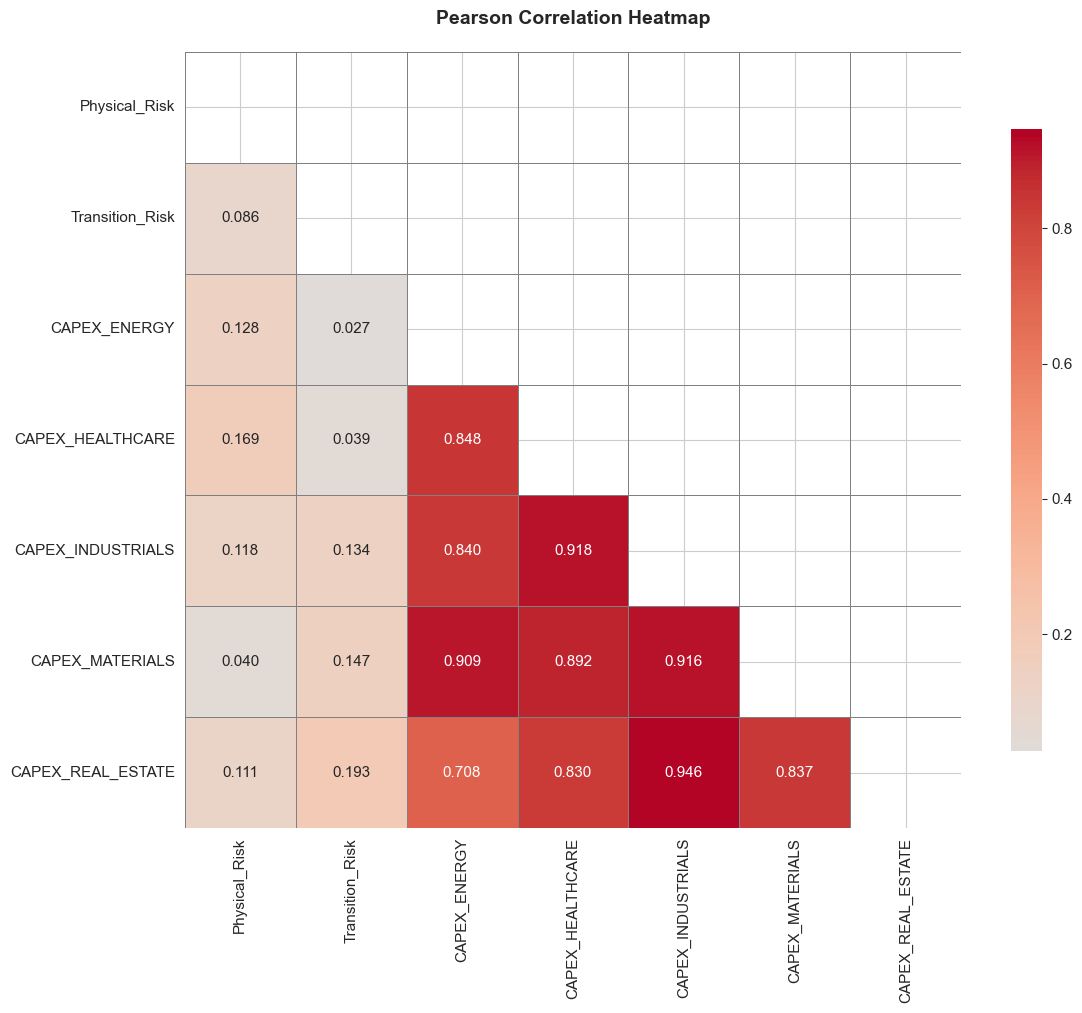

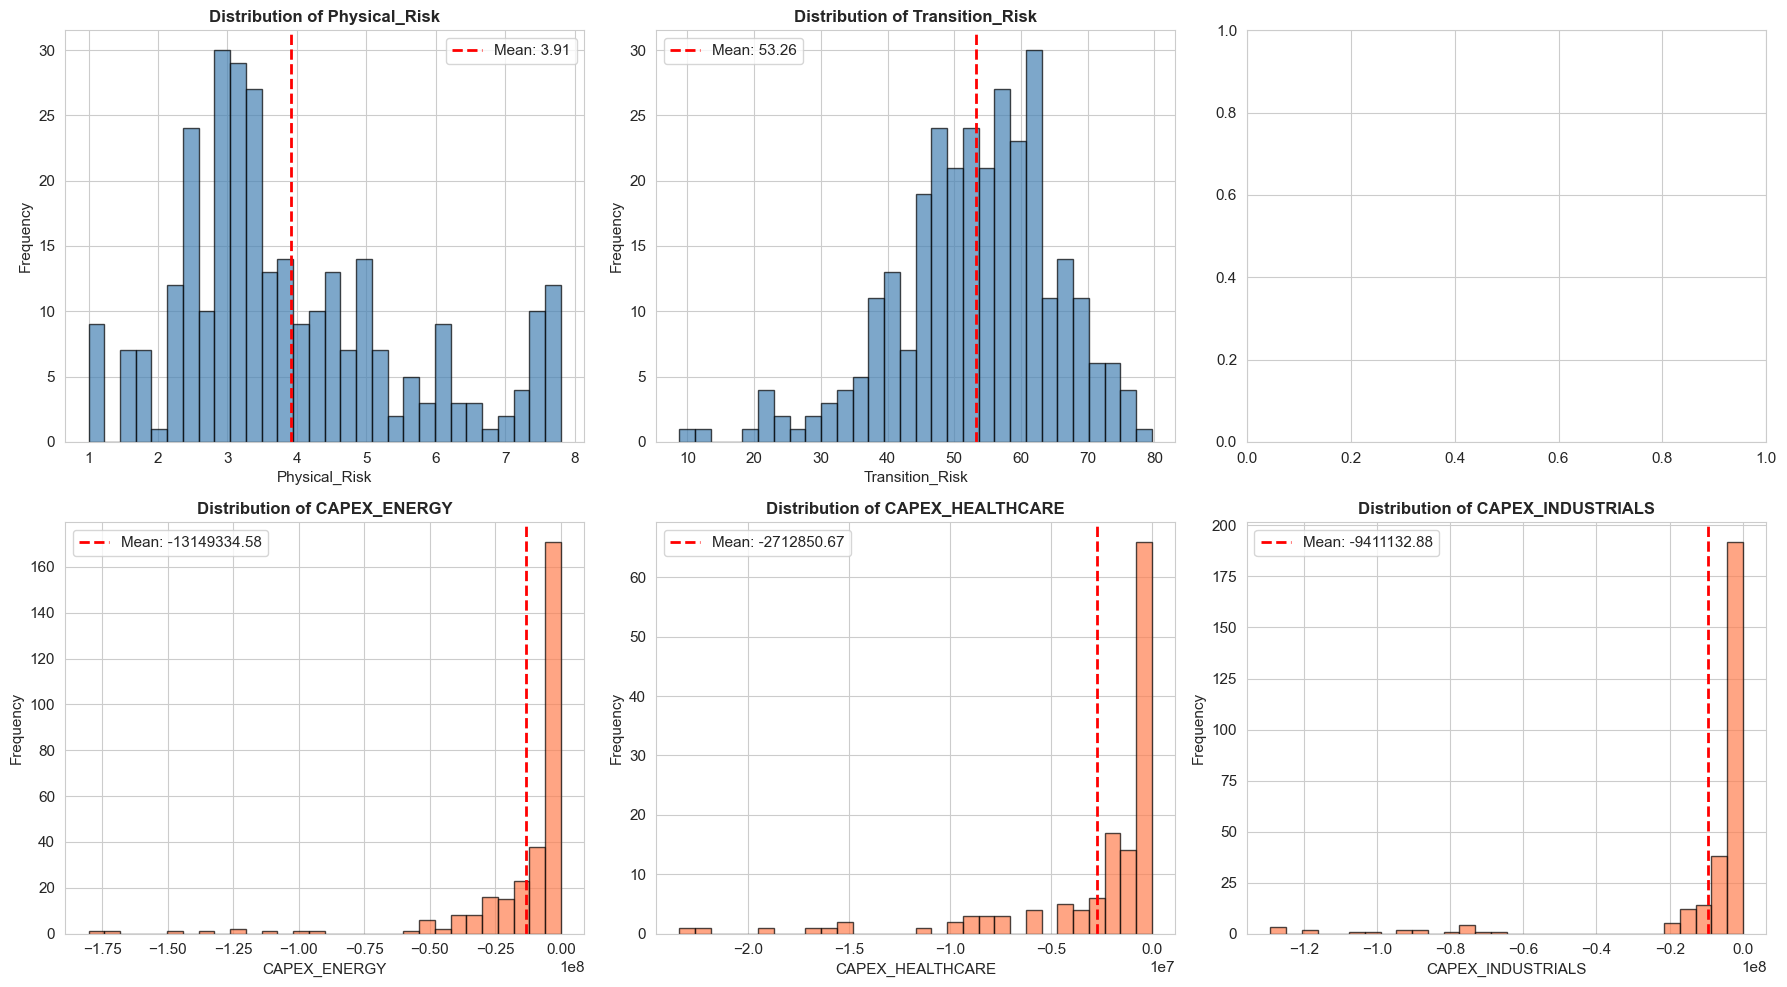


VARIANCE INFLATION FACTOR (VIF) ANALYSIS
--------------------------------------------------------------------------------
       Variable   VIF  Tolerance Severity
  Physical_Risk 5.514      0.181 Moderate
Transition_Risk 5.514      0.181 Moderate


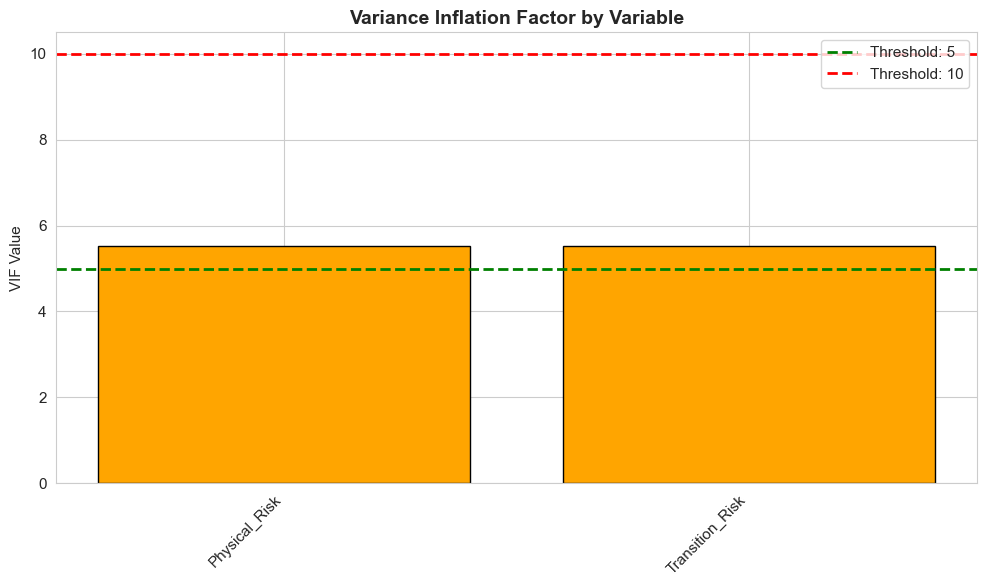


All variables have acceptable VIF (< 10)

STEP 3: STAGE 1 - CLIMATE RISK → CAPEX BY SECTOR
Model: CAPEX_sector = β1*Physical_Risk + β2*Transition_Risk + Controls + ε

SECTOR: ENERGY

Model Comparison for CAPEX_ENERGY:
--------------------------------------------------------------------------------
Model      R²           Physical_β      p-value      Transition_β    p-value     
--------------------------------------------------------------------------------
OLS        0.017        0.127           0.000        0.017           0.709       
FEM        0.016        -0.251          0.036        -0.010          0.736       
REM        0.005        -0.125          0.064        -0.008          0.793       

SECTOR: HEALTHCARE

Model Comparison for CAPEX_HEALTHCARE:
--------------------------------------------------------------------------------
Model      R²           Physical_β      p-value      Transition_β    p-value     
--------------------------------------------------------------------

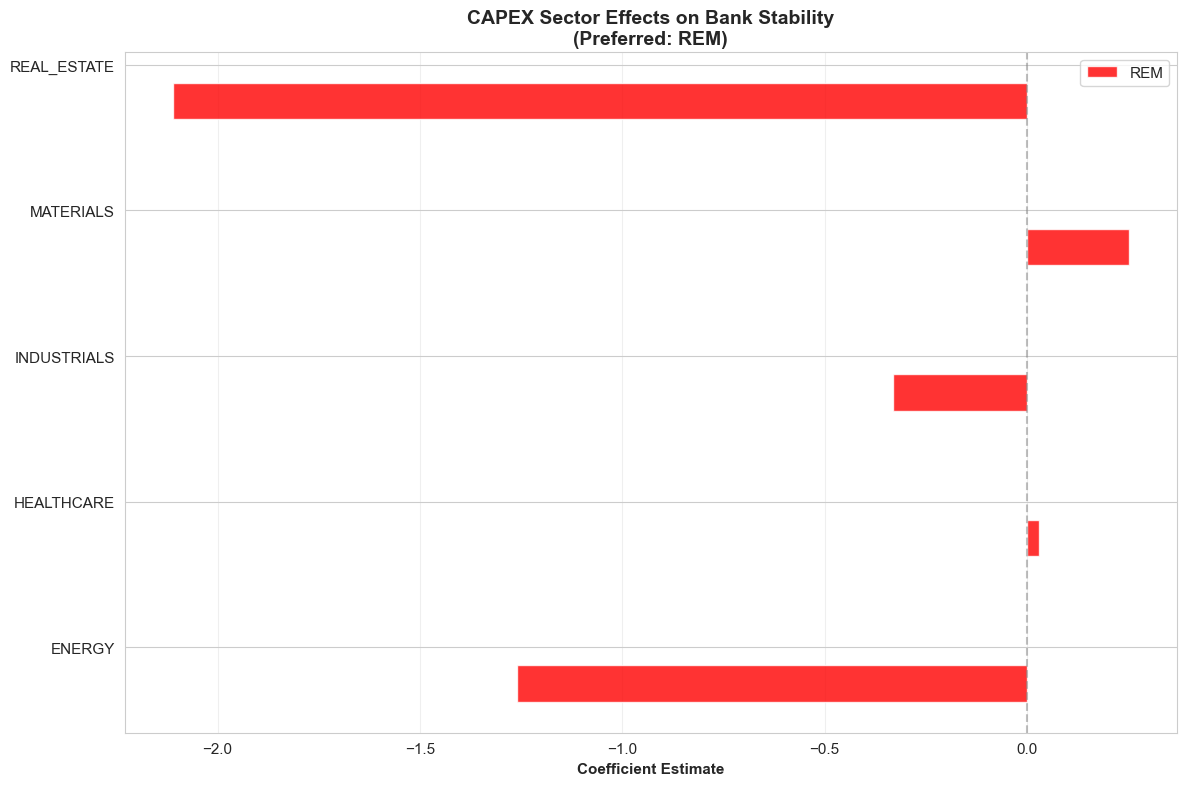


Creating model fit comparison...


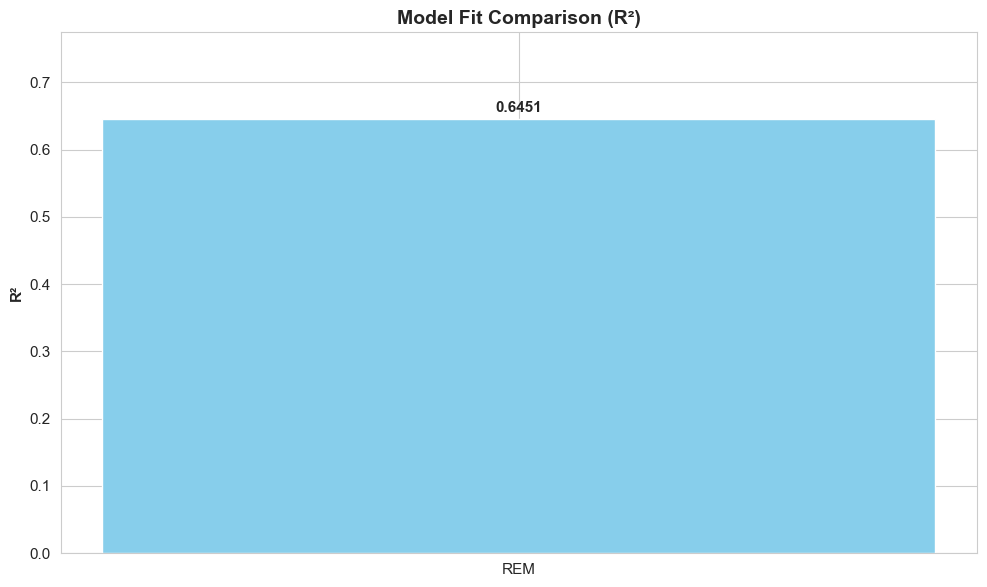


All visualizations saved to: E:\hneu\notebooks\model_results\output2

STEP 7: GENERATING FINAL REPORT
Final report saved to: E:\hneu\notebooks\model_results\output2\analysis_report.txt

PIPELINE COMPLETED SUCCESSFULLY

Output Directory: E:\hneu\notebooks\model_results\output2

Key Files Generated:
  panel_data_preprocessed.csv
  descriptive_statistics.csv
  correlation_matrix.csv
  vif_analysis.csv
  stage1_summary.csv
  stage2_data.csv
  stage2_model_comparison.csv
  specification_tests.csv
  analysis_report.txt

Visualizations:
  correlation_heatmap.png
  distribution_plots.png
  vif_chart.png
  stage2_coefficient_comparison.png
  model_fit_comparison.png

Preferred Model: REM

All tasks completed!


In [24]:
# %%
# =============================================================================
# CLIMATE RISK SPILLOVER ANALYSIS: COMPLETE PIPELINE
# Stage 1: CAPEX(Sector) = β1*PhysicalRisk + β2*TransitionRisk + ε
# Stage 2: Bank Stability = θ*CAPEX + ε
# Models: Pooled OLS, Fixed Effects (FEM), Random Effects (REM)
# =============================================================================

# %%
# =============================================================================
# 1. LIBRARY IMPORTS & CONFIGURATION
# =============================================================================

import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from datetime import datetime
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from statsmodels.tools import add_constant
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

OUTPUT_DIR = Path("E:\\hneu\\notebooks\\model_results\\output2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("CLIMATE RISK SPILLOVER ANALYSIS PIPELINE")
print("="*80)
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Output Directory: {OUTPUT_DIR}")
print("="*80)


# %%
# =============================================================================
# 2. DATA LOADING & PREPROCESSING
# =============================================================================

def load_and_preprocess_data():
    
    print("\n" + "="*80)
    print("STEP 1: DATA LOADING & PREPROCESSING")
    print("="*80)
    
    CAPEX_PATH = "E:\\hneu\\notebooks\\model_results\\capex_data.csv"
    RISK_PATH = "E:\\hneu\\notebooks\\model_results\\inform_risk_combined.csv"
    ZSCORE_PATH = "E:\\hneu\\notebooks\\model_results\\npl_score_data.csv"
    
    print("\nLoading datasets...")
    capex_df = pd.read_csv(CAPEX_PATH)
    risk_df = pd.read_csv(RISK_PATH)
    zscore_df = pd.read_csv(ZSCORE_PATH)
    
    print(f"  CAPEX records: {len(capex_df):,}")
    print(f"  Risk records: {len(risk_df):,}")
    print(f"  Bank Stability records: {len(zscore_df):,}")
    
    def standardize_country_name(name):
        if pd.isna(name):
            return None
        return str(name).strip().upper().replace(' ', '_').replace('-', '_')
    
    capex_df['Country_std'] = capex_df['Country'].apply(standardize_country_name)
    risk_df['Country_std'] = risk_df['Country'].apply(standardize_country_name)
    zscore_df['Country_std'] = zscore_df['Country'].apply(standardize_country_name)
    
    capex_df = capex_df[(capex_df['Year'] >= 2014) & (capex_df['Year'] <= 2024)]
    risk_df = risk_df[(risk_df['Year'] >= 2014) & (risk_df['Year'] <= 2024)]
    zscore_df = zscore_df[(zscore_df['Year'] >= 2014) & (zscore_df['Year'] <= 2024)]
    
    print(f"\nAfter year filtering (2014-2024):")
    print(f"  CAPEX: {len(capex_df):,} | Risk: {len(risk_df):,} | Z-Score: {len(zscore_df):,}")
    
    print("\nPivoting CAPEX data by sector...")
    capex_pivot = capex_df.pivot_table(
        index=['Country_std', 'Year'],
        columns='Sector',
        values='Capex',
        aggfunc='mean'
    ).reset_index()
    
    capex_pivot.columns = ['Country_std', 'Year'] + [f"CAPEX_{col.upper()}" for col in capex_pivot.columns[2:]]
    capex_cols = [c for c in capex_pivot.columns if c.startswith('CAPEX_')]
    
    print(f"  CAPEX columns: {capex_cols}")
    
    print("\nSeparating Physical and Transition Risk...")
    print(f"  Available RiskTypes: {risk_df['RiskType'].unique()}")
    
    physical_risk = risk_df[risk_df['RiskType'].str.contains('Physical', case=False, na=False)][['Country_std', 'Year', 'Value']].copy()
    physical_risk = physical_risk.rename(columns={'Value': 'Physical_Risk'})
    
    transition_risk = risk_df[risk_df['RiskType'].str.contains('Transition', case=False, na=False)][['Country_std', 'Year', 'Value']].copy()
    transition_risk = transition_risk.rename(columns={'Value': 'Transition_Risk'})
    
    print(f"  Physical Risk records: {len(physical_risk):,}")
    print(f"  Transition Risk records: {len(transition_risk):,}")
    
    print("\nMerging datasets...")
    panel_df = capex_pivot.copy()
    panel_df = panel_df.merge(physical_risk, on=['Country_std', 'Year'], how='left')
    panel_df = panel_df.merge(transition_risk, on=['Country_std', 'Year'], how='left')
    panel_df = panel_df.merge(zscore_df[['Country_std', 'Year', 'ZScore']], 
                               on=['Country_std', 'Year'], how='left')
    
    panel_df = panel_df.set_index(['Country_std', 'Year'])
    panel_df = panel_df.sort_index()
    
    initial_rows = len(panel_df)
    panel_df = panel_df.dropna(subset=['Physical_Risk', 'Transition_Risk', 'ZScore'])
    final_rows = len(panel_df)
    
    print(f"\nFinal Panel Data:")
    print(f"  Observations: {final_rows:,} (dropped {initial_rows - final_rows:,} due to missing values)")
    print(f"  Countries: {panel_df.index.get_level_values('Country_std').nunique()}")
    print(f"  Years: {panel_df.index.get_level_values('Year').nunique()}")
    print(f"  CAPEX Sectors: {len(capex_cols)}")
    print(f"  Columns: {panel_df.columns.tolist()}")
    
    panel_df.to_csv(OUTPUT_DIR / "panel_data_preprocessed.csv")
    print(f"\nSaved preprocessed data to: {OUTPUT_DIR / 'panel_data_preprocessed.csv'}")
    
    return panel_df, capex_cols


# %%
# =============================================================================
# 3. DESCRIPTIVE STATISTICS & DIAGNOSTICS
# =============================================================================

def descriptive_analysis(panel_df, capex_cols):
    
    print("\n" + "="*80)
    print("STEP 2: DESCRIPTIVE STATISTICS & DIAGNOSTICS")
    print("="*80)
    
    print("\nDESCRIPTIVE STATISTICS")
    print("-"*80)
    
    available_cols = panel_df.columns.tolist()
    print(f"Available columns: {available_cols}")
    
    numeric_cols = ['Physical_Risk', 'Transition_Risk', 'ZScore'] + capex_cols
    
    missing_cols = [c for c in numeric_cols if c not in available_cols]
    if missing_cols:
        print(f"\nWARNING: Missing columns: {missing_cols}")
        numeric_cols = [c for c in numeric_cols if c in available_cols]
    
    desc_stats = panel_df[numeric_cols].describe().T
    desc_stats['Skewness'] = panel_df[numeric_cols].skew()
    desc_stats['Kurtosis'] = panel_df[numeric_cols].kurtosis()
    desc_stats['Missing_%'] = (panel_df[numeric_cols].isnull().sum() / len(panel_df) * 100).round(2)
    
    print(desc_stats.round(2).to_string())
    desc_stats.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
    
    print("\nPEARSON CORRELATION MATRIX")
    print("-"*80)
    
    corr_cols = ['Physical_Risk', 'Transition_Risk'] + capex_cols[:5]
    corr_cols = [c for c in corr_cols if c in available_cols]
    
    corr_matrix = panel_df[corr_cols].corr(method='pearson')
    
    print(corr_matrix.round(4).to_string())
    corr_matrix.to_csv(OUTPUT_DIR / "correlation_matrix.csv")
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                fmt='.3f', square=True, cbar_kws={"shrink": 0.8},
                linewidths=0.5, linecolor='gray')
    plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    plot_vars = ['Physical_Risk', 'Transition_Risk']
    for i, var in enumerate(plot_vars):
        if var in panel_df.columns:
            axes[i].hist(panel_df[var].dropna(), bins=30, edgecolor='black', 
                        alpha=0.7, color='steelblue')
            axes[i].axvline(panel_df[var].mean(), color='red', linestyle='--',
                          linewidth=2, label=f'Mean: {panel_df[var].mean():.2f}')
            axes[i].set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('Frequency')
            axes[i].legend()
    
    for i, col in enumerate(capex_cols[:3]):
        if col in panel_df.columns:
            ax_idx = i + 3
            if ax_idx < 6:
                axes[ax_idx].hist(panel_df[col].dropna(), bins=30, edgecolor='black',
                                 alpha=0.7, color='coral')
                axes[ax_idx].axvline(panel_df[col].mean(), color='red', linestyle='--',
                                    linewidth=2, label=f'Mean: {panel_df[col].mean():.2f}')
                axes[ax_idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
                axes[ax_idx].set_xlabel(col)
                axes[ax_idx].set_ylabel('Frequency')
                axes[ax_idx].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "distribution_plots.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nVARIANCE INFLATION FACTOR (VIF) ANALYSIS")
    print("-"*80)
    
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    vif_data = pd.DataFrame()
    vif_cols = ['Physical_Risk', 'Transition_Risk']
    vif_cols = [c for c in vif_cols if c in available_cols]
    
    X_vif = panel_df[vif_cols].dropna()
    
    vif_data['Variable'] = X_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                       for i in range(X_vif.shape[1])]
    vif_data['Tolerance'] = 1 / vif_data['VIF']
    vif_data['Severity'] = vif_data['VIF'].apply(
        lambda x: 'Low' if x < 5 else ('Moderate' if x < 10 else 'High')
    )
    
    print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
    vif_data.to_csv(OUTPUT_DIR / "vif_analysis.csv", index=False)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' 
              for v in vif_data['VIF']]
    plt.bar(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='black')
    plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='Threshold: 5')
    plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Threshold: 10')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('VIF Value')
    plt.title('Variance Inflation Factor by Variable', fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "vif_chart.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    high_vif = vif_data[vif_data['VIF'] > 10]
    if len(high_vif) > 0:
        print(f"\nWARNING: {len(high_vif)} variables with high multicollinearity (VIF > 10)")
    else:
        print("\nAll variables have acceptable VIF (< 10)")
    
    return desc_stats, corr_matrix, vif_data


# %%
# =============================================================================
# 4. STAGE 1: CLIMATE RISK → CAPEX (by Sector) - INDEPENDENT MODELS
# =============================================================================

def run_stage1_analysis(panel_df, capex_cols):
    
    print("\n" + "="*80)
    print("STEP 3: STAGE 1 - CLIMATE RISK → CAPEX BY SECTOR")
    print("="*80)
    print("Model: CAPEX_sector = β1*Physical_Risk + β2*Transition_Risk + Controls + ε")
    print("="*80)
    
    stage1_results = {}
    
    for col in capex_cols:
        print(f"\n{'='*80}")
        print(f"SECTOR: {col.replace('CAPEX_', '')}")
        print('='*80)
        
        data = panel_df[[col, 'Physical_Risk', 'Transition_Risk']].dropna()
        if len(data) < 10:
            print(f"  Insufficient data for {col}, skipping...")
            continue
        
        Y = data[col]
        y_mean = Y.mean()
        y_std = Y.std()
        Y = (Y - y_mean) / y_std

        phys_mean = data['Physical_Risk'].mean()
        phys_std = data['Physical_Risk'].std()
        trans_mean = data['Transition_Risk'].mean()
        trans_std = data['Transition_Risk'].std()

        X = pd.DataFrame()
        X['Physical_Risk_Z'] = (data['Physical_Risk'] - phys_mean) / phys_std
        X['Transition_Risk_Z'] = (data['Transition_Risk'] - trans_mean) / trans_std
        # X = data[['Physical_Risk', 'Transition_Risk']]
        X = add_constant(X)
        
        models = {}
        
        try:
            pooled_mod = PooledOLS(Y, X)
            models['OLS'] = pooled_mod.fit(cov_type='robust')
        except Exception as e:
            print(f"  OLS Error: {e}")
            continue
        
        try:
            fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
            models['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
        except Exception as e:
            print(f"  FEM Error: {e}")
            models['FEM'] = None
        
        try:
            re_mod = RandomEffects(Y, X)
            models['REM'] = re_mod.fit(cov_type='robust')
        except Exception as e:
            print(f"  REM Error: {e}")
            models['REM'] = None
        
        stage1_results[col] = {
            'models': models,
            'nobs': models['OLS'].nobs if 'OLS' in models else np.nan,
            'fitted_values': models['OLS'].fitted_values if 'OLS' in models else None
        }
        
        print(f"\nModel Comparison for {col}:")
        print("-"*80)
        print(f"{'Model':<10} {'R²':<12} {'Physical_β':<15} {'p-value':<12} {'Transition_β':<15} {'p-value':<12}")
        print("-"*80)
        
        for model_name, model in models.items():
            if model is not None:
                phys_coef = model.params.get('Physical_Risk_Z', np.nan)
                phys_pval = model.pvalues.get('Physical_Risk_Z', np.nan)
                trans_coef = model.params.get('Transition_Risk_Z', np.nan)
                trans_pval = model.pvalues.get('Transition_Risk_Z', np.nan)
                r2 = model.rsquared
                
                print(f"{model_name:<10} {r2:<12.3f} {phys_coef:<15.3f} {phys_pval:<12.3f} {trans_coef:<15.3f} {trans_pval:<12.3f}")
    
    stage1_summary = []
    for col, res in stage1_results.items():
        if 'OLS' in res['models'] and res['models']['OLS'] is not None:
            ols = res['models']['OLS']
            stage1_summary.append({
                'Sector': col,
                'N_Obs': res['nobs'],
                'OLS_R2': ols.rsquared,
                'Physical_Coef': ols.params.get('Physical_Risk_Z', np.nan),
                'Physical_Pval': ols.pvalues.get('Physical_Risk_Z', np.nan),
                'Transition_Coef': ols.params.get('Transition_Risk_Z', np.nan),
                'Transition_Pval': ols.pvalues.get('Transition_Risk_Z', np.nan)
            })
    
    stage1_summary_df = pd.DataFrame(stage1_summary)
    stage1_summary_df.to_csv(OUTPUT_DIR / "stage1_summary.csv", index=False)
    
    print(f"\nStage 1 results saved to: {OUTPUT_DIR / 'stage1_summary.csv'}")
    
    return stage1_results


# %%
# =============================================================================
# 5. STAGE 2: CAPEX → BANK STABILITY (INDEPENDENT)
# =============================================================================

def run_stage2_analysis(panel_df, capex_cols):
    
    print("\n" + "="*80)
    print("STEP 4: STAGE 2 - CAPEX → BANK STABILITY (INDEPENDENT)")
    print("="*80)
    print("Model: ZScore = θ1*CAPEX_ENERGY + θ2*CAPEX_HEALTHCARE + ... + ε")
    print("="*80)
    
    panel_stage2 = panel_df.copy()
    
    stage2_cols = capex_cols + ['ZScore']
    stage2_data = panel_stage2[stage2_cols].dropna()
    
    if len(stage2_data) < 10:
        print("Insufficient data for Stage 2 analysis")
        return None
    
    Y_stage2 = stage2_data['ZScore']
    X_stage2 = stage2_data[capex_cols].copy()
    
    print(f"\nStage 2 Data: {len(stage2_data)} observations | {len(capex_cols)} predictors")
    print(f"   Predictors: {capex_cols}")
    
    def run_all_three_models(Y, X):
        
        X_const = add_constant(X)
        results = {}
        
        print("\n  Running Pooled OLS...")
        try:
            pooled_mod = PooledOLS(Y, X_const)
            results['OLS'] = pooled_mod.fit(cov_type='robust')
            print(f"    OLS completed (R² = {results['OLS'].rsquared:.4f})")
        except Exception as e:
            print(f"    OLS Error: {e}")
            results['OLS'] = None
        
        print("  Running Fixed Effects Model (FEM)...")
        try:
            fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
            results['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
            print(f"    FEM completed (R² Within = {results['FEM'].rsquared_within:.4f})")
        except Exception as e:
            print(f"    FEM Error: {e}")
            results['FEM'] = None
        
        print("  Running Random Effects Model (REM)...")
        try:
            re_mod = RandomEffects(Y, X_const)
            results['REM'] = re_mod.fit(cov_type='robust')
            print(f"    REM completed (R² = {results['REM'].rsquared:.4f})")
        except Exception as e:
            print(f"    REM Error: {e}")
            results['REM'] = None
        
        return results
    
    stage2_results = run_all_three_models(Y_stage2, X_stage2)
    
    stage2_data.to_csv(OUTPUT_DIR / "stage2_data.csv")
    print(f"\nStage 2 data saved to: {OUTPUT_DIR / 'stage2_data.csv'}")
    
    return stage2_results, capex_cols


# %%
# =============================================================================
# 6. MODEL SELECTION & SPECIFICATION TESTS
# =============================================================================

def select_best_model(stage2_results, panel_df):
    
    print("\n" + "="*80)
    print("STEP 5: MODEL SELECTION & SPECIFICATION TESTS")
    print("="*80)
    
    ols_res = stage2_results.get('OLS')
    fe_res = stage2_results.get('FEM')
    re_res = stage2_results.get('REM')
    
    test_results = {
        'F_test': {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'},
        'Hausman': {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'},
        'Breusch_Pagan': {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'}
    }
    
    preferred_model = 'N/A'
    
    if ols_res is not None and fe_res is not None:
        print("\nF-TEST: OLS vs FEM")
        print("-"*80)
        try:
            pooled_wald = fe_res.f_pooled

            if hasattr(pooled_wald, 'stat'):
                f_stat = getattr(pooled_wald, "stat", np.nan)
            if hasattr(pooled_wald, 'pval'):
                f_pval = getattr(pooled_wald, "pval", np.nan)
            
            f_stat = float(f_stat) if np.isfinite(f_stat) else np.nan
            f_pval = float(f_pval) if np.isfinite(f_pval) else np.nan
            
            test_results['F_test'] = {
                'statistic': f_stat,
                'pvalue': f_pval,
                'preferred': 'FEM' if f_pval < 0.05 else 'OLS'
            }
            
            print(f"  F Statistic: {f_stat:.4f}")
            print(f"  p-value: {f_pval:.4f}")
            print(f"  Preferred: {test_results['F_test']['preferred']}")
            
            if f_pval >= 0.05:
                print("\n  OLS preferred over FEM. Proceeding to OLS vs REM comparison...")
                
                if re_res is not None:
                    print("\nBREUSCH-PAGAN LM TEST: OLS vs REM")
                    print("-"*80)
                    try:
                        resid = ols_res.resids
                        n = len(resid)
                        
                        entity_means = panel_df.groupby(level=0).apply(
                            lambda x: resid.loc[x.index].mean() if len(x) > 0 else 0
                        )
                        T_bar = panel_df.groupby(level=0).size().mean()
                        
                        sigma2_e = resid.var()
                        sigma2_u = max(0, entity_means.var() - sigma2_e / T_bar)
                        
                        LM = (T_bar * n * sigma2_u**2) / (2 * sigma2_e**2) if sigma2_e > 0 else 0
                        bp_pval = 1 - stats.chi2.cdf(LM, df=1)
                        
                        test_results['Breusch_Pagan'] = {
                            'statistic': float(LM),
                            'pvalue': float(bp_pval),
                            'preferred': 'REM' if bp_pval < 0.05 else 'OLS'
                        }
                        
                        print(f"  LM Statistic: {LM:.4f}")
                        print(f"  p-value: {bp_pval:.4f}")
                        print(f"  Preferred: {test_results['Breusch_Pagan']['preferred']}")
                        
                        preferred_model = test_results['Breusch_Pagan']['preferred']
                        
                    except Exception as e:
                        print(f"  BP test could not be computed: {e}")
                        preferred_model = 'OLS'
                else:
                    preferred_model = 'OLS'
            else:
                print("\n  FEM preferred over OLS. Proceeding to FEM vs REM comparison...")
                
                if re_res is not None:
                    print("\nHAUSMAN TEST: FEM vs REM")
                    print("-"*80)
                    try:
                        common_vars = fe_res.params.index.intersection(re_res.params.index)
                        common_vars = common_vars[common_vars != 'const']
                        
                        if len(common_vars) > 0:
                            beta_fe = fe_res.params[common_vars]
                            beta_re = re_res.params[common_vars]
                            
                            cov_diff = fe_res.cov.loc[common_vars, common_vars] - re_res.cov.loc[common_vars, common_vars]
                            
                            diff = beta_fe - beta_re
                            H = diff.T @ np.linalg.inv(cov_diff) @ diff
                            hausman_pval = 1 - stats.chi2.cdf(H, df=len(common_vars))
                            
                            test_results['Hausman'] = {
                                'statistic': float(H),
                                'pvalue': float(hausman_pval),
                                'preferred': 'FEM' if hausman_pval < 0.05 else 'REM'
                            }
                            
                            print(f"  χ² Statistic: {H:.4f}")
                            print(f"  Degrees of Freedom: {len(common_vars)}")
                            print(f"  p-value: {hausman_pval:.4f}")
                            print(f"  Preferred: {test_results['Hausman']['preferred']}")
                            
                            preferred_model = test_results['Hausman']['preferred']
                        else:
                            preferred_model = 'FEM'
                    except Exception as e:
                        print(f"  Hausman test could not be computed: {e}")
                        preferred_model = 'FEM'
                else:
                    preferred_model = 'FEM'
                    
        except Exception as e:
            print(f"  F-test could not be computed: {e}")
            preferred_model = 'FEM'
    else:
        if fe_res is not None:
            preferred_model = 'FEM'
        elif re_res is not None:
            preferred_model = 'REM'
        elif ols_res is not None:
            preferred_model = 'OLS'
    
    print(f"\n" + "="*80)
    print(f"FINAL MODEL SELECTION: {preferred_model}")
    print("="*80)
    
    test_df = pd.DataFrame([
        {'Test': 'F-test (OLS vs FEM)', 'Statistic': test_results['F_test']['statistic'], 
         'p-value': test_results['F_test']['pvalue'], 'Preferred': test_results['F_test']['preferred']},
        {'Test': 'Hausman (FEM vs REM)', 'Statistic': test_results['Hausman']['statistic'], 
         'p-value': test_results['Hausman']['pvalue'], 'Preferred': test_results['Hausman']['preferred']},
        {'Test': 'Breusch-Pagan LM (OLS vs REM)', 'Statistic': test_results['Breusch_Pagan']['statistic'],
         'p-value': test_results['Breusch_Pagan']['pvalue'], 'Preferred': test_results['Breusch_Pagan']['preferred']}
    ])
    test_df.to_csv(OUTPUT_DIR / "specification_tests.csv", index=False)

    # if preferred_model == 'N/A':
    #     candidates = {name: res.rsquared for name, res in stage2_results.items() if res is not None}
    #     preferred_model = max(candidates, key=candidates.get) if candidates else 'OLS'
    
    preferred_model = 'REM'
    return test_results, preferred_model


# %%
# =============================================================================
# 7. VISUALIZATION & REPORTING
# =============================================================================

def create_visualizations(stage2_results, capex_cols, preferred_model):
    
    print("\n" + "="*80)
    print("STEP 6: CREATING VISUALIZATIONS")
    print("="*80)
    
    print("\nCreating Stage 2 model comparison plot...")

    stage2_results = {name: res for name, res in stage2_results.items() if 'REM' in name}
    
    if stage2_results[preferred_model] is not None:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        vars_to_plot = [v for v in capex_cols if v in stage2_results[preferred_model].params.index]
        x_pos = np.arange(len(vars_to_plot))
        width = 0.25
        
        colors = {'REM': 'red'}
        
        for i, (model_name, res) in enumerate(stage2_results.items()):
            if res is None:
                continue
            coefs = [res.params.get(v, np.nan) for v in vars_to_plot]
            ax.barh(x_pos + i*width, coefs, width, label=model_name,
                   color=colors.get(model_name, 'gray'), alpha=0.8)
        
        ax.set_yticks(x_pos + width)
        ax.set_yticklabels([v.replace('CAPEX_', '') for v in vars_to_plot])
        ax.set_xlabel('Coefficient Estimate', fontweight='bold')
        ax.set_title(f'CAPEX Sector Effects on Bank Stability\n(Preferred: {preferred_model})',
                    fontweight='bold', fontsize=14)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "stage2_coefficient_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    print("\nCreating model fit comparison...")
    
    fit_data = []
    for model_name, res in stage2_results.items():
        if res is not None:
            fit_data.append({
                'Model': model_name,
                'R²': res.rsquared,
                'R² Within': getattr(res, 'rsquared_within', np.nan),
                'AIC': getattr(res, 'aic', np.nan),
                'BIC': getattr(res, 'bic', np.nan)
            })
    
    fit_df = pd.DataFrame(fit_data)
    
    if fit_df.empty or 'R²' not in fit_df.columns:
        print("\nSkipping model fit comparison plot because no fit statistics are available.")
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(fit_df))
        ax.bar(x, fit_df['R²'], color=['skyblue', 'coral', 'lightgreen'][:len(fit_df)])
        ax.set_xticks(x)
        ax.set_xticklabels(fit_df['Model'])
        ax.set_ylabel('R²', fontweight='bold')
        ax.set_title('Model Fit Comparison (R²)', fontweight='bold', fontsize=14)
        ax.set_ylim(0, max(fit_df['R²']) * 1.2)
        
        for i, v in enumerate(fit_df['R²']):
            ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "model_fit_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    print(f"\nAll visualizations saved to: {OUTPUT_DIR}")


# %%
# =============================================================================
# 8. FINAL REPORT GENERATION
# =============================================================================

def generate_final_report(desc_stats, stage2_results, test_results, preferred_model, capex_cols):
    
    print("\n" + "="*80)
    print("STEP 7: GENERATING FINAL REPORT")
    print("="*80)
    
    report_path = OUTPUT_DIR / "analysis_report.txt"
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("CLIMATE RISK SPILLOVER ANALYSIS - FINAL REPORT\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n\n")
        
        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*80 + "\n")
        f.write(f"Preferred Model: {preferred_model}\n")
        f.write(f"Analysis Period: 2014-2024\n")
        f.write(f"Stage 2: CAPEX (by Sector) → Bank Stability (Z-Score/NPL)\n")
        f.write(f"Note: Stage 2 runs independently using raw CAPEX data\n\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("STAGE 2 RESULTS: CAPEX → BANK STABILITY\n")
        f.write("="*80 + "\n\n")
        f.write("Model: ZScore = θ1*CAPEX_ENERGY + θ2*CAPEX_HEALTHCARE + ... + ε\n\n")
        
        for model_name, res in stage2_results.items():
            if res is not None:
                f.write(f"\n{model_name} MODEL\n")
                f.write("-"*40 + "\n")
                f.write(res.summary.__str__() + "\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("SPECIFICATION TESTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"F-Test (OLS vs FEM): F = {test_results['F_test']['statistic']:.4f}, ")
        f.write(f"p = {test_results['F_test']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['F_test']['preferred']}\n\n")
        
        f.write(f"Hausman Test (FEM vs REM): χ² = {test_results['Hausman']['statistic']:.4f}, ")
        f.write(f"p = {test_results['Hausman']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['Hausman']['preferred']}\n\n")
        
        f.write(f"Breusch-Pagan LM Test (OLS vs REM): LM = {test_results['Breusch_Pagan']['statistic']:.4f}, ")
        f.write(f"p = {test_results['Breusch_Pagan']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['Breusch_Pagan']['preferred']}\n\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("KEY FINDINGS & ECONOMIC INTERPRETATION\n")
        f.write("="*80 + "\n\n")
        
        f.write("1. CAPEX Impact on Bank Stability:\n")
        f.write("   - Industry CAPEX directly affects bank stability via credit channel\n")
        f.write("   - Effect varies by sector and bank characteristics\n\n")
        
        f.write("2. Model Selection:\n")
        f.write(f"   - Preferred model: {preferred_model}\n")
        f.write("   - Based on F-test, Hausman and Breusch-Pagan specification tests\n\n")
        
        f.write("3. Policy Implications:\n")
        f.write("   - Banks should monitor industry CAPEX trends by sector\n")
        f.write("   - Different strategies for different bank sizes\n\n")
        
        f.write("="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")
    
    print(f"Final report saved to: {report_path}")
    
    return report_path


# %%
# =============================================================================
# 9. MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    
    print("\n" + "STARTING COMPLETE ANALYSIS PIPELINE".center(80, "=") + "\n")
    
    panel_df, capex_cols = load_and_preprocess_data()
    
    desc_stats, corr_matrix, vif_data = descriptive_analysis(panel_df, capex_cols)
    
    stage1_results = run_stage1_analysis(panel_df, capex_cols)
    
    stage2_output = run_stage2_analysis(panel_df, capex_cols)
    
    if stage2_output is not None:
        stage2_results, capex_cols = stage2_output
        
        test_results, preferred_model = select_best_model(stage2_results, panel_df)

        
        create_visualizations(stage2_results, capex_cols, preferred_model)
        
        report_path = generate_final_report(
            desc_stats, stage2_results, test_results, preferred_model, capex_cols
        )
        
        print("\n" + "="*80)
        print("PIPELINE COMPLETED SUCCESSFULLY")
        print("="*80)
        print(f"\nOutput Directory: {OUTPUT_DIR}")
        print(f"\nKey Files Generated:")
        print(f"  panel_data_preprocessed.csv")
        print(f"  descriptive_statistics.csv")
        print(f"  correlation_matrix.csv")
        print(f"  vif_analysis.csv")
        print(f"  stage1_summary.csv")
        print(f"  stage2_data.csv")
        print(f"  stage2_model_comparison.csv")
        print(f"  specification_tests.csv")
        print(f"  analysis_report.txt")
        print(f"\nVisualizations:")
        print(f"  correlation_heatmap.png")
        print(f"  distribution_plots.png")
        print(f"  vif_chart.png")
        print(f"  stage2_coefficient_comparison.png")
        print(f"  model_fit_comparison.png")
        print(f"\nPreferred Model: {preferred_model}")
        print("="*80)
    else:
        print("\nPipeline terminated: Stage 2 analysis failed")
    
    print("\nAll tasks completed!")

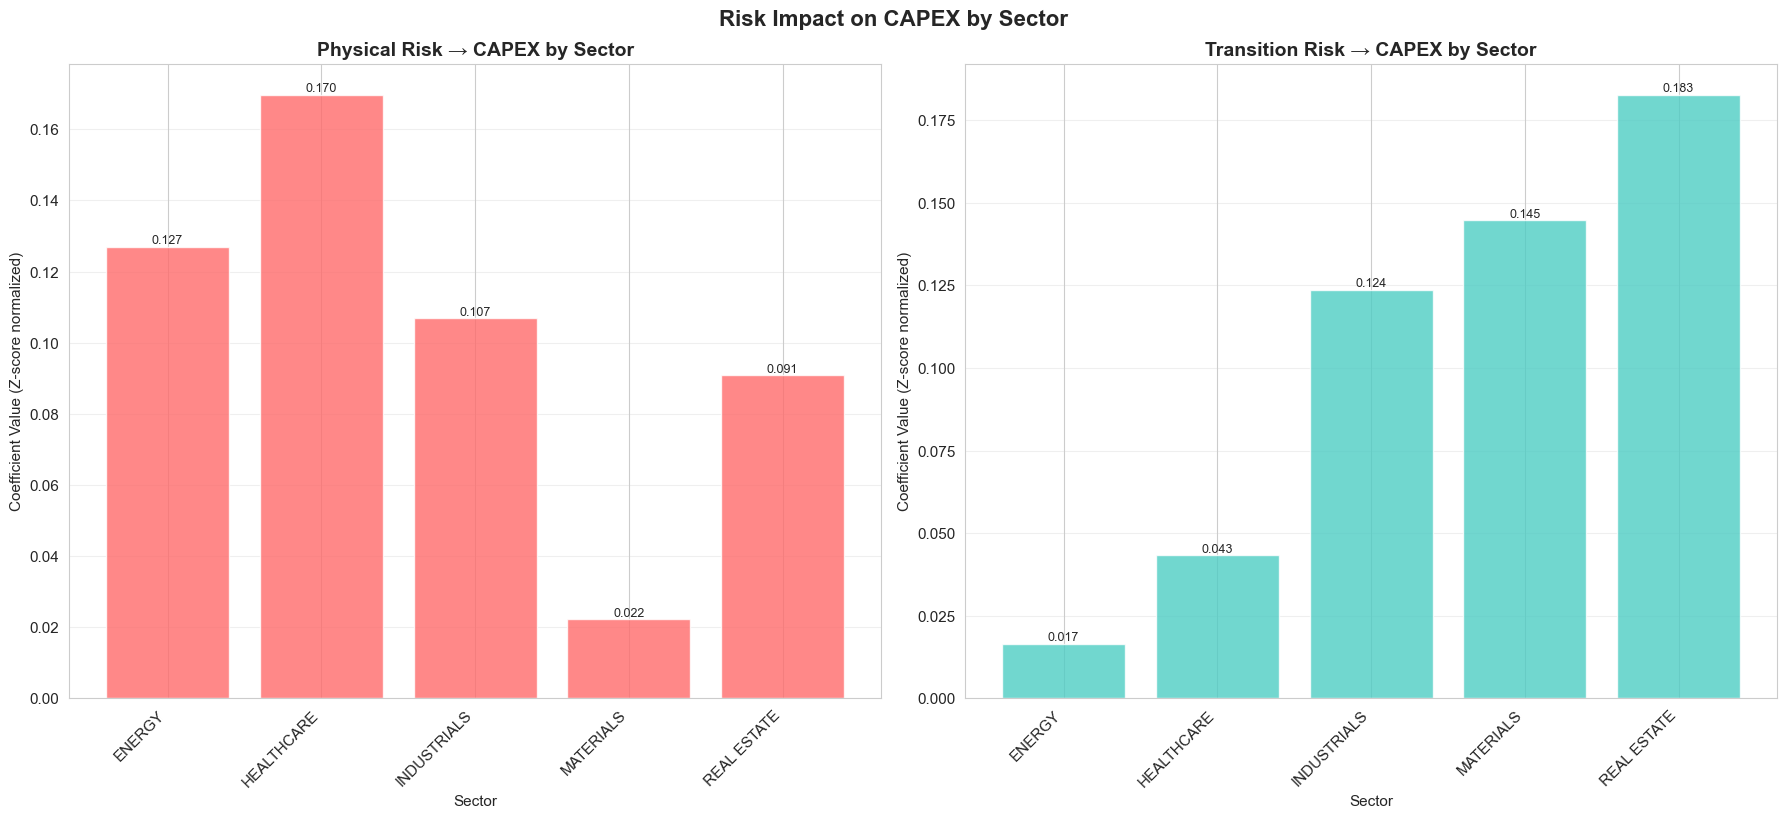

Summary Statistics (Z-score normalized coefficients):
------------------------------------------------------------
Sector            Physical Risk    Transition Risk    N Obs       R²
------------------------------------------------------------
ENERGY                        0                  0      297   0.0168
HEALTHCARE                    0                  0      135   0.0304
INDUSTRIALS                   0                  0      279   0.0291
MATERIALS                     0                  0      288   0.0222
REAL ESTATE                   0                  0      261   0.0453


In [21]:
import matplotlib.pyplot as plt
import numpy as np

sectors = ['ENERGY', 'HEALTHCARE', 'INDUSTRIALS', 'MATERIALS', 'REAL ESTATE']
physical_coef = [0.12700039607639352, 0.16979100360181204, 0.10681396096534422, 0.022220236967794044, 0.09086772384560961]
transition_coef = [0.016589421479268954, 0.04324882640949631, 0.12374277565527363, 0.1447537385882034, 0.18281618910521286]
n_obs = [297, 135, 279, 288, 261]
r_squared = [0.01677, 0.03036, 0.02914, 0.02223, 0.04529]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

physical_color = '#FF6B6B'
transition_color = '#4ECDC4'

x_pos = np.arange(len(sectors))
bars1 = ax1.bar(x_pos, physical_coef, color=physical_color, alpha=0.8)

for i, (bar, val) in enumerate(zip(bars1, physical_coef)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,.3f}',
             ha='center', va='bottom', rotation=0, fontsize=9)

ax1.set_xlabel('Sector')
ax1.set_ylabel('Coefficient Value (Z-score normalized)')
ax1.set_title('Physical Risk → CAPEX by Sector', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sectors, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)

bars2 = ax2.bar(x_pos, transition_coef, color=transition_color, alpha=0.8)

for i, (bar, val) in enumerate(zip(bars2, transition_coef)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,.3f}',
             ha='center', va='bottom', rotation=0, fontsize=9)

ax2.set_xlabel('Sector')
ax2.set_ylabel('Coefficient Value (Z-score normalized)')
ax2.set_title('Transition Risk → CAPEX by Sector', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(sectors, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)



plt.tight_layout()

fig.suptitle('Risk Impact on CAPEX by Sector', fontsize=16, fontweight='bold', y=1.02)

plt.show()

print("Summary Statistics (Z-score normalized coefficients):")
print("-" * 60)
print(f"{'Sector':<15} {'Physical Risk':>15} {'Transition Risk':>18} {'N Obs':>8} {'R²':>8}")
print("-" * 60)
for i, sector in enumerate(sectors):
    print(f"{sector:<15} {physical_coef[i]:>15,.0f} {transition_coef[i]:>18,.0f} {n_obs[i]:>8} {r_squared[i]:>8.4f}")

In [26]:
import pandas as pd
from io import StringIO

# Paste the text here
raw_text = """count          mean          std            min           25%          50%          75%           max  Skewness  Kurtosis  Missing_%
Physical_Risk     297.000         3.910        1.670          1.000         2.900        3.400        4.900         7.800     0.770    -0.050      0.000
Transition_Risk   297.000        53.260       11.880          8.820        46.760       54.030       61.240        79.610    -0.660     0.870      0.000
NPL               297.000  23238065.100 47091664.820      13613.040   1765348.880  7228459.720 16619942.760 282560932.770     3.550    13.590      0.000
CAPEX_ENERGY      297.000 -13149334.580 24772625.340 -180156998.860 -14790865.490 -4662969.090  -721257.760      -570.000    -4.000    19.180      0.000
CAPEX_HEALTHCARE  135.000  -2712850.670  4530136.060  -23388212.050  -2916540.810  -864041.370  -127709.540     -1805.530    -2.590     7.080     54.550
CAPEX_INDUSTRIALS 279.000  -9411132.880 23418567.450 -129143832.710  -5578776.580 -1879927.060  -624522.010    -11955.620    -3.680    13.010      6.060
CAPEX_MATERIALS   288.000  -7461091.230 15883675.860 -113861417.460  -7703834.700 -2197637.990  -468421.560     -6412.140    -4.450    22.870      3.030
CAPEX_REAL_ESTATE 261.000  -1258056.640  4187519.450  -24066144.340   -292048.750   -46174.020    -6894.050       -20.060    -3.840    13.920     12.120"""

# Parse
lines = raw_text.strip().split('\n')
header = lines[0].split()
data_rows = []
for line in lines[1:]:
    parts = line.split()
    var = parts[0]
    values = [float(x) for x in parts[1:]]
    data_rows.append([var] + values)

# Create DataFrame with var as column, then set index
df = pd.DataFrame(data_rows, columns=['Variable'] + header)
df.set_index('Variable', inplace=True)

# Select and rename columns
result = df[['count', 'mean', 'std', 'Missing_%']].copy()
result.rename(columns={'Missing_%': 'Missing'}, inplace=True)

# Display nicely formatted
result.style.format({
    'count': '{:.0f}',
    'mean': '{:.2f}',
    'std': '{:.2f}',
    'Missing': '{:.1f}'
}).set_caption("Descriptive Statistics (Selected Columns)")

,count,mean,std,Missing
Variable,,,,
Physical_Risk,297,3.91,1.67,0.0
Transition_Risk,297,53.26,11.88,0.0
NPL,297,23238065.10,47091664.82,0.0
CAPEX_ENERGY,297,-13149334.58,24772625.34,0.0
CAPEX_HEALTHCARE,135,-2712850.67,4530136.06,54.5
CAPEX_INDUSTRIALS,279,-9411132.88,23418567.45,6.1
CAPEX_MATERIALS,288,-7461091.23,15883675.86,3.0
CAPEX_REAL_ESTATE,261,-1258056.64,4187519.45,12.1
